## Задача 01 — EDA: Анализ Страховых Выплат

### 📋 Контекст: Ты аналитик в страховой компании. Нужно исследовать датасет с клиентами перед построением модели предсказания страховых выплат.

### 📦 Датасет

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

np.random.seed(42)
n = 1338

df = pd.DataFrame({
    'age':      np.random.randint(18, 65, n),
    'sex':      np.random.choice(['male', 'female'], n),
    'bmi':      np.round(np.random.normal(30, 6, n), 1),
    'children': np.random.randint(0, 5, n),
    'smoker':   np.random.choice(['yes', 'no'], n, p=[0.2, 0.8]),
    'region':   np.random.choice(['northeast', 'northwest', 'southeast', 'southwest'], n),
    'charges':  np.abs(np.random.normal(13000, 12000, n)),
})
df.loc[np.random.choice(n, 50), 'bmi'] = np.nan
df.loc[np.random.choice(n, 30), 'age'] = np.nan
df.loc[5, 'bmi'] = 85.0       # выброс
df.loc[10, 'charges'] = -500  # аномалия

## Часть 1 — Базовое исследование


### 1.1. Размер, типы колонок, пропуски, дубликаты.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1308 non-null   float64
 1   sex       1338 non-null   object 
 2   bmi       1290 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 73.3+ KB


In [ ]:
df.isna().sum()

,0
age,30
sex,0
bmi,48
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()

np.int64(0)

### 1.2. Для числовых колонок: mean, median, std, min, max, Q1, Q3, skewness, kurtosis. Какие имеют |skew| > 1?

In [ ]:
df.describe()

,age,bmi,children,charges
count,1308.000000,1290.000000,1338.000000,1338.000000
mean,41.053517,29.871318,2.076981,14810.526003
std,13.490234,6.110029,1.389961,10016.788092
min,18.000000,9.200000,0.000000,-500.000000
25%,29.000000,25.800000,1.000000,6859.936969
50%,42.000000,30.000000,2.000000,13816.779750
75%,52.000000,33.800000,3.000000,21625.722155
max,64.000000,85.000000,4.000000,56193.601368


In [ ]:
df_skewness = df.skew(numeric_only=True)
df_skewness

,0
age,-0.056703
bmi,0.503859
children,-0.072566
charges,0.636971


In [ ]:
df_kurtosis = df.kurtosis(numeric_only=True)
df_kurtosis

,0
age,-1.153295
bmi,4.758891
children,-1.253321
charges,-0.052957


In [ ]:
df_skewness[abs(df_skewness) > 1]

,0


#### Никакие данные не имеют |skew| > 1

### 1.3. Для категориальных: уникальные значения, частоты, дисбаланс.

#### Уникальные значения

In [ ]:
categorical_value = df.select_dtypes(exclude = "number")
for col in categorical_value:
  display(col, df[col].unique())

'sex'

array(['male', 'female'], dtype=object)

'smoker'

array(['yes', 'no'], dtype=object)

'region'

array(['northwest', 'southwest', 'southeast', 'northeast'], dtype=object)

#### Количество уникальных значений(частоты)

In [ ]:
for col in categorical_value:
   display(df[col].value_counts())

,count
sex,
male,678
female,660


,count
smoker,
no,1065
yes,273


,count
region,
northwest,354
southeast,335
northeast,325
southwest,324


Дисбаланс категориальный переменных

In [ ]:
for col in categorical_value:
   display(df[col].value_counts(normalize= True) * 100)

,proportion
sex,
male,50.672646
female,49.327354


,proportion
smoker,
no,79.596413
yes,20.403587


,proportion
region,
northwest,26.457399
southeast,25.037369
northeast,24.289985
southwest,24.215247


### 1.4. Найди аномалии: отрицательный charges, bmi > 60, age < 0 или > 100.

In [ ]:
anomalies = df[
    (df['charges'] < 0) |
    (df['bmi'] > 60) |
    (df['age'] < 0) |
    (df['age'] > 100)
]

anomalies

,age,sex,bmi,children,smoker,region,charges
5,38.0,female,85.0,4,yes,southeast,20833.000987
10,28.0,female,23.0,3,no,northwest,-500.000000


## Часть 2 — Распределения

### 2.1. Гистограмма + KDE для каждой числовой колонки. Опиши форму каждого распределения.

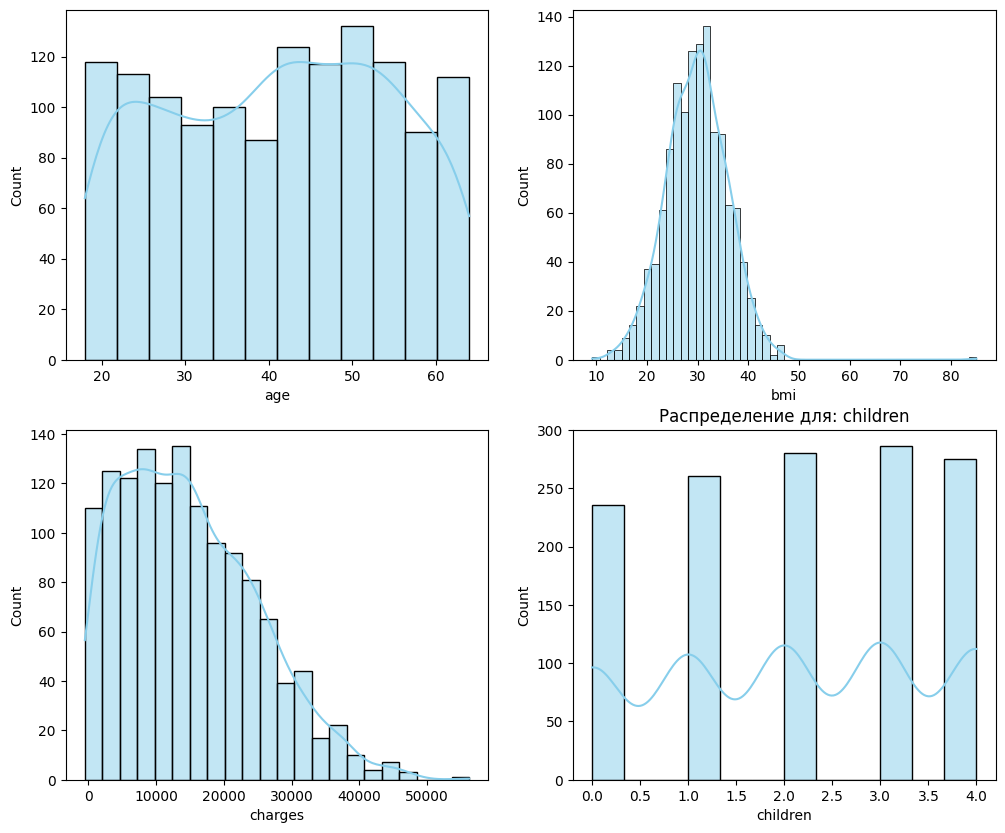

In [ ]:
numeric_cat = ['age', 'bmi', 'charges', 'children']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cat):
  sns.histplot(df[col], kde=True, color="skyblue", ax = axes[i])
  plt.title(f"Распределение для: {col}")
plt.show()

#### 1. Распределение возраста: гистограмма показывает количество застрахованных людей от возраста. Можно заметить, что старшее поколение (40+) преобладает в количестве.
#### 2.Распределение для bmi: гистограмма показывает распределение индекса массы тела к количеству застрахованных людей. Пик приходится на 25-30 индекс тела, что явялется избыточным весом
#### 3.Распределение трат: основная масса собрана от 0 до 19.000, дальше идет резкий спад. По гистограмме можно сделать вывод, что не все люди много отдают на страховые взносы
#### 4. Распределение для children: от 0 до 3 легкое увеличение, в дальнейшем уже уменьшение

### 2.2. Boxplot charges по: smoker, sex, region. Какой фактор влияет сильнее?

/tmp/ipykernel_3009/170711424.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="charges", ax=axes[i], palette="Set2")
/tmp/ipykernel_3009/170711424.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="charges", ax=axes[i], palette="Set2")
/tmp/ipykernel_3009/170711424.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="charges", ax=axes[i], palette="Set2")


<function matplotlib.pyplot.show(close=None, block=None)>

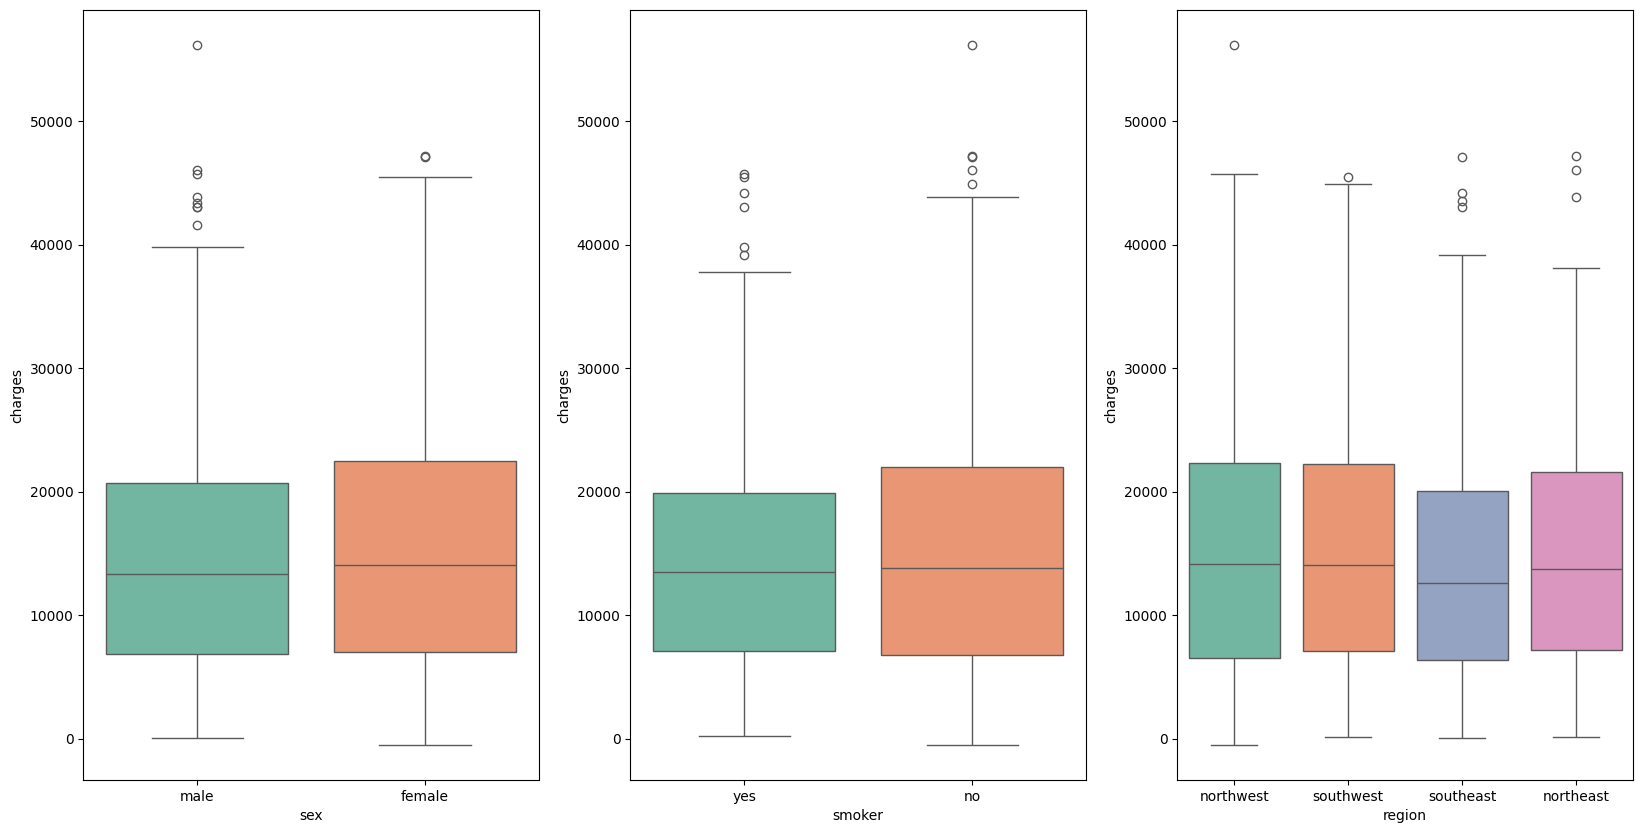

In [ ]:
categorical_value = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate (categorical_value):
  sns.boxplot(data=df, x=col, y="charges", ax=axes[i], palette="Set2")
plt.suptitle('')
plt.show

#### По графикам "ящик с усами" сильного влияния нет нигде, больше по значения влияет регион

### 2.3. Scatter plot bmi vs charges, раскрашенный по smoker. Что видно?

<Axes: xlabel='bmi', ylabel='charges'>

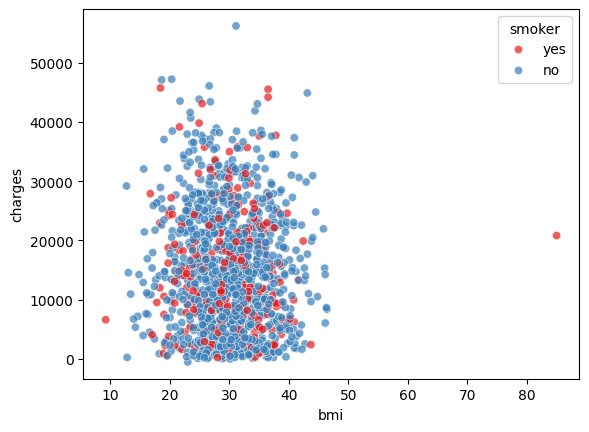

In [ ]:
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", palette="Set1",alpha=0.7)

#### Курящие чаще имеют более высокие charges, особенно при одинаковом BMI. Основная масса людей имеет BMI примерно 20–40.

## Часть 3 — Корреляции

### Матрица Pearson корреляций. Топ-3 признака по корреляции с charges.

#### Преобразуем категориальные признаки в числовые значения

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_copy = df.copy()
le = LabelEncoder()
df_copy['smoker'] = le.fit_transform(df['smoker'])
df_copy['sex'] = le.fit_transform(df['sex'])
df_copy['region'] = le.fit_transform(df['region'])

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1308 non-null   float64
 1   sex       1338 non-null   int64  
 2   bmi       1290 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 73.3 KB


### Матрица корреляций + топ 3 признака

,charges
children,0.067511
age,0.025620
region,0.000623


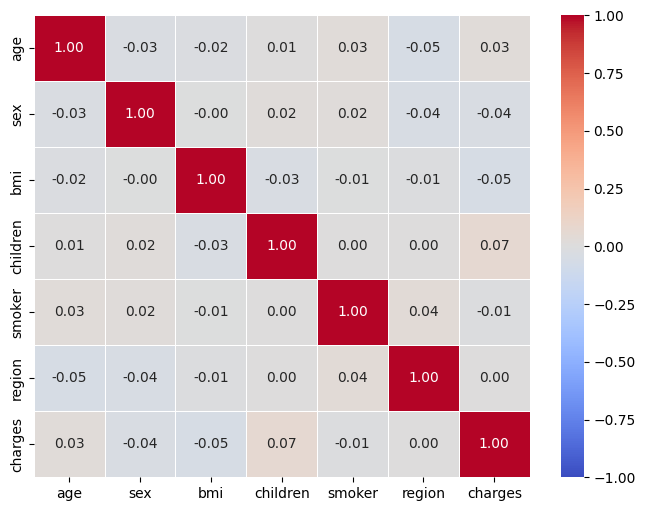

In [ ]:
corr_matrix = df_copy.corr(method="pearson")
plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
top3 = corr_matrix["charges"].drop("charges").sort_values(ascending=False).head(3)
top3

### 3.2. Повтори для Spearman. Отличия?

,charges
children,0.066714
age,0.028966
smoker,-0.005918


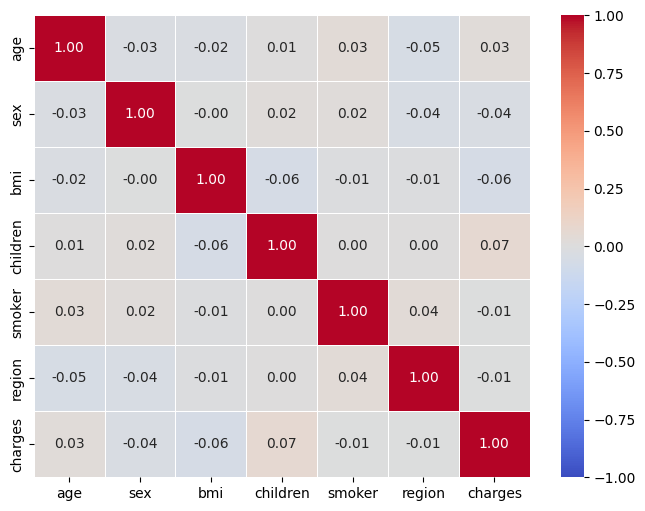

In [ ]:
corr_matrix = df_copy.corr(method="spearman")
plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
top3 = corr_matrix["charges"].drop("charges").sort_values(ascending=False).head(3)
top3

#### Spearman анализирует кривую функцию, Pearson - прямую. Отличий особых нет, что означает связи очень слабые

### 3.3. Бинаризируй smoker (0/1) и посчитай корреляцию с charges.

In [ ]:
corr_matrix["charges"].smoker



np.float64(-0.005917870147213779)

## Часть 4 — Статистические тесты (бонус ⭐)

### 4.1. Тест Шапиро-Уилка на нормальность charges.

In [ ]:
from scipy import stats

shapiro_stat, p_value = stats.shapiro(df["charges"])

print(f"Статистика теста (W): {shapiro_stat:.4f}")
print(f"p-value: {p_value}")

alpha = 0.05
if p_value > alpha:
    print(
        "Распределение НОРМАЛЬНОЕ (Не удалось отвергнуть нулевую гипотезу H0)"
    )
else:
    print(
        "Распределение НЕ НОРМАЛЬНОЕ (Отвергаем H0, данные отклоняются от нормального вида)"
    )


Статистика теста (W): 0.9581
p-value: 3.7560493959882125e-19
Распределение НЕ НОРМАЛЬНОЕ (Отвергаем H0, данные отклоняются от нормального вида)


#### По результатам теста Шапиро–Уилка получено p-value ≈ 3.76 × 10^-19, что значительно меньше уровня значимости alpha = 0.05. Поэтому нулевая гипотеза о нормальности распределения отвергается. Распределение charges не является нормальным

### 4.2. t-тест: отличаются ли charges у курящих и некурящих? p-value и вывод.

In [ ]:

charges_smoker = df[df["smoker"] == "yes"]["charges"]
charges_non_smoker = df[df["smoker"] == "no"]["charges"]


t_stat, t_p_value = stats.ttest_ind(charges_smoker, charges_non_smoker, equal_var=False)
print("--- T-тест Стьюдента (Уэлча) ---")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {t_p_value}")


u_stat, u_p_value = stats.mannwhitneyu(charges_smoker, charges_non_smoker)
print("\n--- U-критерий Манна-Уитни ---")
print(f"u-статистика: {u_stat:.4f}")
print(f"p-value: {u_p_value}")


--- T-тест Стьюдента (Уэлча) ---
t-статистика: -0.3818
p-value: 0.7027977439872377

--- U-критерий Манна-Уитни ---
u-статистика: 144140.0000
p-value: 0.828754531926899


#### По результатам t-теста Стьюдента получено p-value = 0.7028, а по U-критерию Манна–Уитни — p-value = 0.8288. Оба значения значительно больше уровня значимости alpha = 0.05, поэтому нулевая гипотеза не отвергается. Следовательно, статистически значимых различий в charges между курящими и некурящими по результатам этих тестов не обнаружено.


### Создай bmi_category (underweight/normal/overweight/obese), проанализируй charges по ней.

In [ ]:

bins = [0, 18.5, 25, 30, np.inf]
labels = ["Underweight", "Normal", "Overweight", "Obese"]


df["bmi_category"] = pd.cut(df["bmi"], bins=bins, labels=labels, right=False)

analysis = (df.groupby("bmi_category", observed=False)["charges"].agg(Количество_людей="count", Среднее="mean", Медиана="median", Мин="min", Макс="max").round(2))

print(analysis)


              Количество_людей   Среднее   Медиана     Мин      Макс
bmi_category                                                        
Underweight                 38  14825.82  12578.83  267.02  45728.32
Normal                     219  16835.99  15782.96 -500.00  47209.33
Overweight                 380  14714.69  13462.95   49.64  46079.67
Obese                      653  14252.96  13338.41    6.58  56193.60


#### Больше всего наблюдений в категории Obese — 653 человека. Средние значения charges во всех категориях находятся примерно в диапазоне 14–17 тыс. Наибольшее среднее значение наблюдается у категории Normal — 16835.99, а наименьшее — у Obese — 14252.96. Медианные значения тоже достаточно близки друг к другу. Зависимости charges от bmi явной не наблюдается.

## Вывод:
### 5 инстайтов о данных:
1. Распределение `charges` не является нормальным, распределение имеет сильный разброс и выбросы.
2. `bmi` слабо связан с `charges`
3. Зависимости пола от страховых выплат практически нет, медианные значения на графике "ящик с усами" примерно одинаковы
4. `charges` имеет отрицательные значения по `bmi` в таблице
5. Количество людей в категориях `bmi` заметно различаются

### Список проблем, которые нужно решить до моделирования:
1. Проверить и в случае нахождения - удалить отрицательные значения `charges`
2. Проверить пропуски и устранить их для дальнейшей работы с моделью
3. Проверить и решить проблему с дубликатами, они могут мешать работе
4. Закодировать категориальные значения - не все модели могут работать не с числовыми данными

